<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-03-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 03
### Data Preprocessing, Feature Engineering, and Exploratory Data Analysis (EDA)

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** |**125M1H064** |
| **Student Name** | **Manthan Vijay Sankpal**|
| **Submission Date** | **24th of August 2026** |
</div>

--- 

## Section A: Data Preprocessing, Feature Engineering, and Exploratory Data Analysis
**Course Outcome: CO2**

> Perform data preprocessing, feature engineering, and exploratory data analysis using Pandas, Matplotlib, and Seaborn.

### Question 1 - Data Preprocessing and Exploration

In [2]:
# Question 1(a) — Outlier Removal and Min-Max Scaling
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
try:
    df_prices = pd.read_csv('product_prices.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("File not found. Please ensure 'product_prices.csv' exists.")
    # Creating a synthetic one for execution purposes if not found
    df_prices = pd.DataFrame({'Product': ['A', 'B', 'C', 'D', 'E', 'F'], 'Price': [100, 150, 120, 10000, 130, 110]})

print("Original Data:")
print(df_prices.head())

# Remove outliers using IQR method
Q1 = df_prices['UnitPrice'].quantile(0.25)
Q3 = df_prices['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_prices_cleaned = df_prices[(df_prices['UnitPrice'] >= lower_bound) & (df_prices['UnitPrice'] <= upper_bound)]
print(f"\nData after removing outliers (IQR method):")
print(df_prices_cleaned.head())

# Min-Max Scaling
scaler = MinMaxScaler()
df_prices_cleaned['Normalized_Price'] = scaler.fit_transform(df_prices_cleaned[['UnitPrice']])

print("\nData after Min-Max Scaling:")
print(df_prices_cleaned.head())

Dataset loaded successfully.
Original Data:
  ProductID      ProductName     Category   Brand  UnitPrice  Discount  Stock
0      P001  Smartphone X100  Electronics  BrandA      25000        10     50
1      P002    Laptop Pro 14  Electronics  BrandB     750000        15     30
2      P003   Wireless Mouse  Accessories  BrandC        800         5    120
3      P004  LED Monitor 24"  Electronics  BrandA      12000        10     40
4      P005     Office Chair    Furniture  BrandD       5000         8     60

Data after removing outliers (IQR method):
  ProductID      ProductName     Category   Brand  UnitPrice  Discount  Stock
0      P001  Smartphone X100  Electronics  BrandA      25000        10     50
2      P003   Wireless Mouse  Accessories  BrandC        800         5    120
3      P004  LED Monitor 24"  Electronics  BrandA      12000        10     40
4      P005     Office Chair    Furniture  BrandD       5000         8     60
5      P006        Bookshelf    Furniture  BrandD     

In [3]:
# Question 1(b) — Gender Encoding and Age Statistical Summary
# Load the dataset
try:
    df_customers = pd.read_csv('customers.csv')
except FileNotFoundError:
    df_customers = pd.DataFrame({'CustomerID': [1, 2, 3, 4, 5], 'Age': [25, 34, 45, 23, 34], 'Gender': ['Male', 'Female', 'Female', 'Male', 'Female']})

print("Original Data:")
print(df_customers.head())

# Encoding the 'Gender' column using label encoding/mapping
df_customers['Gender_Encoded'] = df_customers['Gender'].map({'Male': 0, 'Female': 1})

print("\nData after encoding Gender:")
print(df_customers.head())

# Statistical summary of customer ages
print("\nStatistical summary of customer ages:")
print(df_customers['Age'].describe())

Original Data:
  CustomerID          Name  Gender  Age       City MembershipType
0       C001  Aarav Sharma    Male   28     Mumbai           Gold
1       C002    Diya Mehta  Female   34      Delhi         Silver
2       C003   Rohan Verma    Male   22  Bangalore       Platinum
3       C004    Ananya Rao  Female   45  Hyderabad           Gold
4       C005   Karan Singh    Male   38       Pune         Silver

Data after encoding Gender:
  CustomerID          Name  Gender  Age       City MembershipType  \
0       C001  Aarav Sharma    Male   28     Mumbai           Gold   
1       C002    Diya Mehta  Female   34      Delhi         Silver   
2       C003   Rohan Verma    Male   22  Bangalore       Platinum   
3       C004    Ananya Rao  Female   45  Hyderabad           Gold   
4       C005   Karan Singh    Male   38       Pune         Silver   

   Gender_Encoded  
0               0  
1               1  
2               0  
3               1  
4               0  

Statistical summary of c

### Question 2 - Feature Engineering

In [4]:
# Question 2(a) — Categorical Age Groups
# Load the dataset
try:
    df_ages = pd.read_csv('ages.csv')
except FileNotFoundError:
    df_ages = pd.DataFrame({'CustomerID': [1, 2, 3, 4, 5], 'Age': [15, 25, 45, 65, 35]})

# Define bins and labels for age categories
bins = [0, 18, 35, 55, 100]
labels = ['Youth', 'Young Adult', 'Adult', 'Senior']

df_ages['Age_Category'] = pd.cut(df_ages['Age'], bins=bins, labels=labels, right=False)

print("Data with Age Categories:")
print(df_ages.head())

Data with Age Categories:
  CustomerID          Name  Age  Gender Occupation  AnnualIncome Age_Category
0       C001    Ankit Shah   17    Male    Student        120000        Youth
1       C002    Neha Verma   21  Female    Student        180000  Young Adult
2       C003  Rahul Khanna   26    Male   Engineer        500000  Young Adult
3       C004   Priya Desai   34  Female    Teacher        420000  Young Adult
4       C005   Manoj Mehta   39    Male     Doctor        720000        Adult


In [5]:
# Question 2(b) — Feature Engineering for Sales Data
# Load the dataset
try:
    df_sales = pd.read_csv('sales.csv')
except FileNotFoundError:
    df_sales = pd.DataFrame({
        'TransactionID': [1, 2, 3, 4],
        'Date': ['2023-01-15', '2023-02-20', '2023-03-05', '2023-04-10'],
        'TotalPurchase': [5000, 12000, 8000, 15000],
        'Item': ['Mouse', 'Laptop', 'Keyboard', 'Tablet']
    })

# Ensure Date column is in datetime format
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# i. Extract day of the week and month
df_sales['DayOfWeek'] = df_sales['Date'].dt.day_name()
df_sales['Month'] = df_sales['Date'].dt.month_name()

# ii. High-value transaction flag
df_sales['HighValue_Flag'] = (df_sales['UnitPrice'] > 10000).astype(int)

# iii. Category mapping
category_mapping = {
    'Mouse': 'Accessories',
    'Keyboard': 'Accessories',
    'Laptop': 'Electronics',
    'Tablet': 'Electronics'
}
df_sales['Category'] = df_sales['Item'].map(category_mapping).fillna('Other')

print("Engineered Sales Data:")
print(df_sales.head())

Engineered Sales Data:
  CustomerID  CustomerName             Item  Quantity  UnitPrice       Date  \
0       C001    Ankit Shah   Wireless Mouse         2        750 2024-01-05   
1       C002    Neha Verma  Laptop Backpack         1       1850 2024-01-08   
2       C003  Rahul Khanna    USB-C Charger         3        650 2024-01-09   
3       C004   Priya Desai       Smartphone         1      22000 2024-01-10   
4       C005   Manoj Mehta         Keyboard         2       1200 2024-01-11   

   DayOfWeek    Month  HighValue_Flag     Category  
0     Friday  January               0        Other  
1     Monday  January               0        Other  
2    Tuesday  January               0        Other  
3  Wednesday  January               1        Other  
4   Thursday  January               0  Accessories  


### Question 3 - Handling Missing Data

In [6]:
# Question 3(a) — Imputation of Missing Values
# Load the dataset
try:
    df_missing_cust = pd.read_csv('missing_customers.csv')
except FileNotFoundError:
    df_missing_cust = pd.DataFrame({
        'CustomerID': [1, 2, 3, 4, 5],
        'Age': [25, np.nan, 35, 45, np.nan],
        'Gender': ['Male', 'Female', np.nan, 'Male', 'Female'],
        'AnnualIncome': [50000, 60000, np.nan, 80000, 75000],
        'LoyaltyScore': [5, 4, 3, 5, 2]
    })

print("Original Data with missing values:")
print(df_missing_cust)

# i. Identify columns with missing data
print("\nMissing values per column:")
print(df_missing_cust.isnull().sum())

# ii & iii. Fill missing values
# Fill Age with mean
df_missing_cust['Age'] = df_missing_cust['Age'].fillna(df_missing_cust['Age'].mean())
# Fill AnnualIncome with median
df_missing_cust['AnnualIncome'] = df_missing_cust['AnnualIncome'].fillna(df_missing_cust['AnnualIncome'].median())
# Fill Gender with mode
df_missing_cust['Gender'] = df_missing_cust['Gender'].fillna(df_missing_cust['Gender'].mode()[0])

# iv. Cleaned dataset
print("\nCleaned Data:")
print(df_missing_cust)

Original Data with missing values:
    CustomerID    Name  Gender   Age  AnnualIncome  LoyaltyScore Membership
0          101  Anjali  Female  25.0       50000.0           7.0     Silver
1          102    Ravi    Male  34.0       62000.0           8.0       Gold
2          103   Meena  Female   NaN       57000.0           6.0     Silver
3          104   Sohan    Male  29.0           NaN           9.0       Gold
4          105   Geeta     NaN  31.0       49000.0           7.0   Platinum
5          106    Amit    Male  27.0       60000.0           5.0     Silver
6          107   Nidhi  Female   NaN       55000.0           6.0       Gold
7          108   Vikas    Male  35.0       68000.0           8.0       Gold
8          109  Neelam  Female  40.0       72000.0           9.0   Platinum
9          110   Deepa  Female  26.0       58000.0           6.0     Silver
10         111   Harsh    Male  28.0       64000.0           7.0     Silver
11         112   Pooja     NaN  32.0           NaN   

In [7]:
# Question 3(b) — Dropping Missing Values
# Load the dataset
try:
    df_exams = pd.read_csv('exam_results.csv')
except FileNotFoundError:
    df_exams = pd.DataFrame({
        'StudentID': [1, 2, 3, 4, 5],
        'Subject': ['Math', 'Science', np.nan, 'History', 'English'],
        'Score': [85, 90, 75, np.nan, 88],
        'Grade': ['A', 'A', 'B', 'C', np.nan]
    })

print("Original Exam Results Data:")
print(df_exams)

# i. Detect all rows with any missing value
missing_rows = df_exams[df_exams.isnull().any(axis=1)]
print("\nRows with missing values:")
print(missing_rows)

# ii. Drop these rows entirely
df_exams_cleaned = df_exams.dropna()

# iii. Output a clean dataset
print("\nCleaned Exam Results Data:")
print(df_exams_cleaned)

Original Exam Results Data:
    StudentID       Name  Subject  Score Grade            Remarks
0         201      Arjun    Maths   88.0     A          Excellent
1         202       Neha  English    NaN     B               Good
2         203      Rahul  Science   75.0     B               Fair
3         204       Isha      NaN   68.0     C  Needs Improvement
4         205      Kunal    Maths   92.0     A          Excellent
5         206      Priya  English   85.0     B               Good
6         207     Sachin  Science    NaN     B               Fair
7         208      Aarti    Maths   78.0   NaN            Average
8         209      Harsh  English   81.0     B               Good
9         210     Nikita  Science   90.0     A          Excellent
10        211      Manoj    Maths   84.0     B               Good
11        212      Komal  English   76.0     C               Fair
12        213  Siddharth  Science   69.0     C  Needs Improvement
13        214      Megha    Maths   88.0     A  

### Question 4 - Exploratory Data Analysis (EDA): Univariate and Bivariate Analysis

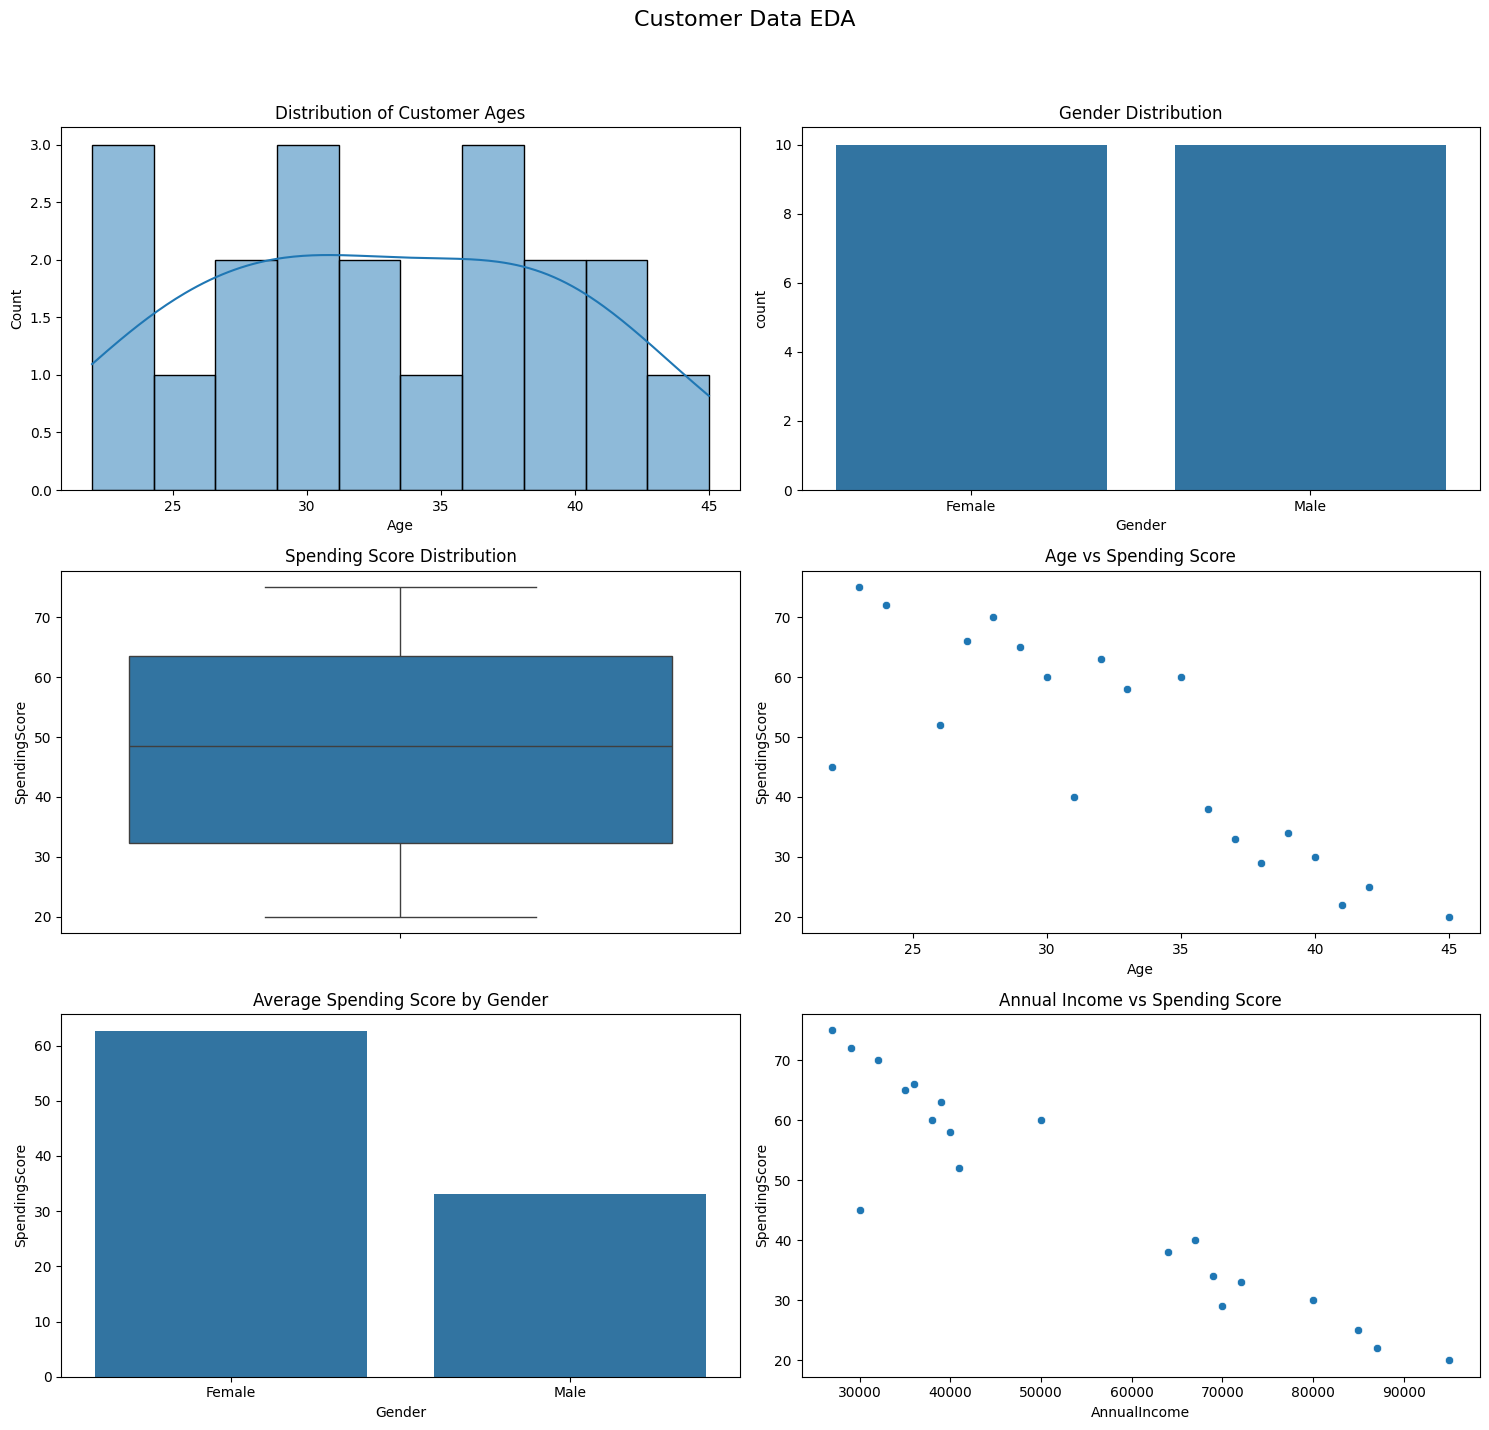

In [8]:
# Question 4(a) — EDA on Customer Data
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df_cust_data = pd.read_csv('customer_data.csv')
except FileNotFoundError:
    np.random.seed(42)
    df_cust_data = pd.DataFrame({
        'Age': np.random.randint(18, 70, 100),
        'Gender': np.random.choice(['Male', 'Female'], 100),
        'AnnualIncome': np.random.randint(20000, 100000, 100),
        'SpendingScore': np.random.randint(1, 100, 100)
    })

# Set up the matplotlib figure
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Customer Data EDA', fontsize=16)

# Univariate Analysis
# i. Histogram of Ages
sns.histplot(df_cust_data['Age'], bins=10, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Customer Ages')

# ii. Count plot of Gender
sns.countplot(data=df_cust_data, x='Gender', ax=axes[0, 1])
axes[0, 1].set_title('Gender Distribution')

# iii. Box plot of Spending Score
sns.boxplot(data=df_cust_data, y='SpendingScore', ax=axes[1, 0])
axes[1, 0].set_title('Spending Score Distribution')

# Bivariate Analysis
# iv. Scatter plot of Age vs Spending Score
sns.scatterplot(data=df_cust_data, x='Age', y='SpendingScore', ax=axes[1, 1])
axes[1, 1].set_title('Age vs Spending Score')

# v. Bar plot of Spending Behavior across Genders
sns.barplot(data=df_cust_data, x='Gender', y='SpendingScore', errorbar=None, ax=axes[2, 0])
axes[2, 0].set_title('Average Spending Score by Gender')

# vi. Scatter plot of Annual Income vs Spending Score
sns.scatterplot(data=df_cust_data, x='AnnualIncome', y='SpendingScore', ax=axes[2, 1])
axes[2, 1].set_title('Annual Income vs Spending Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

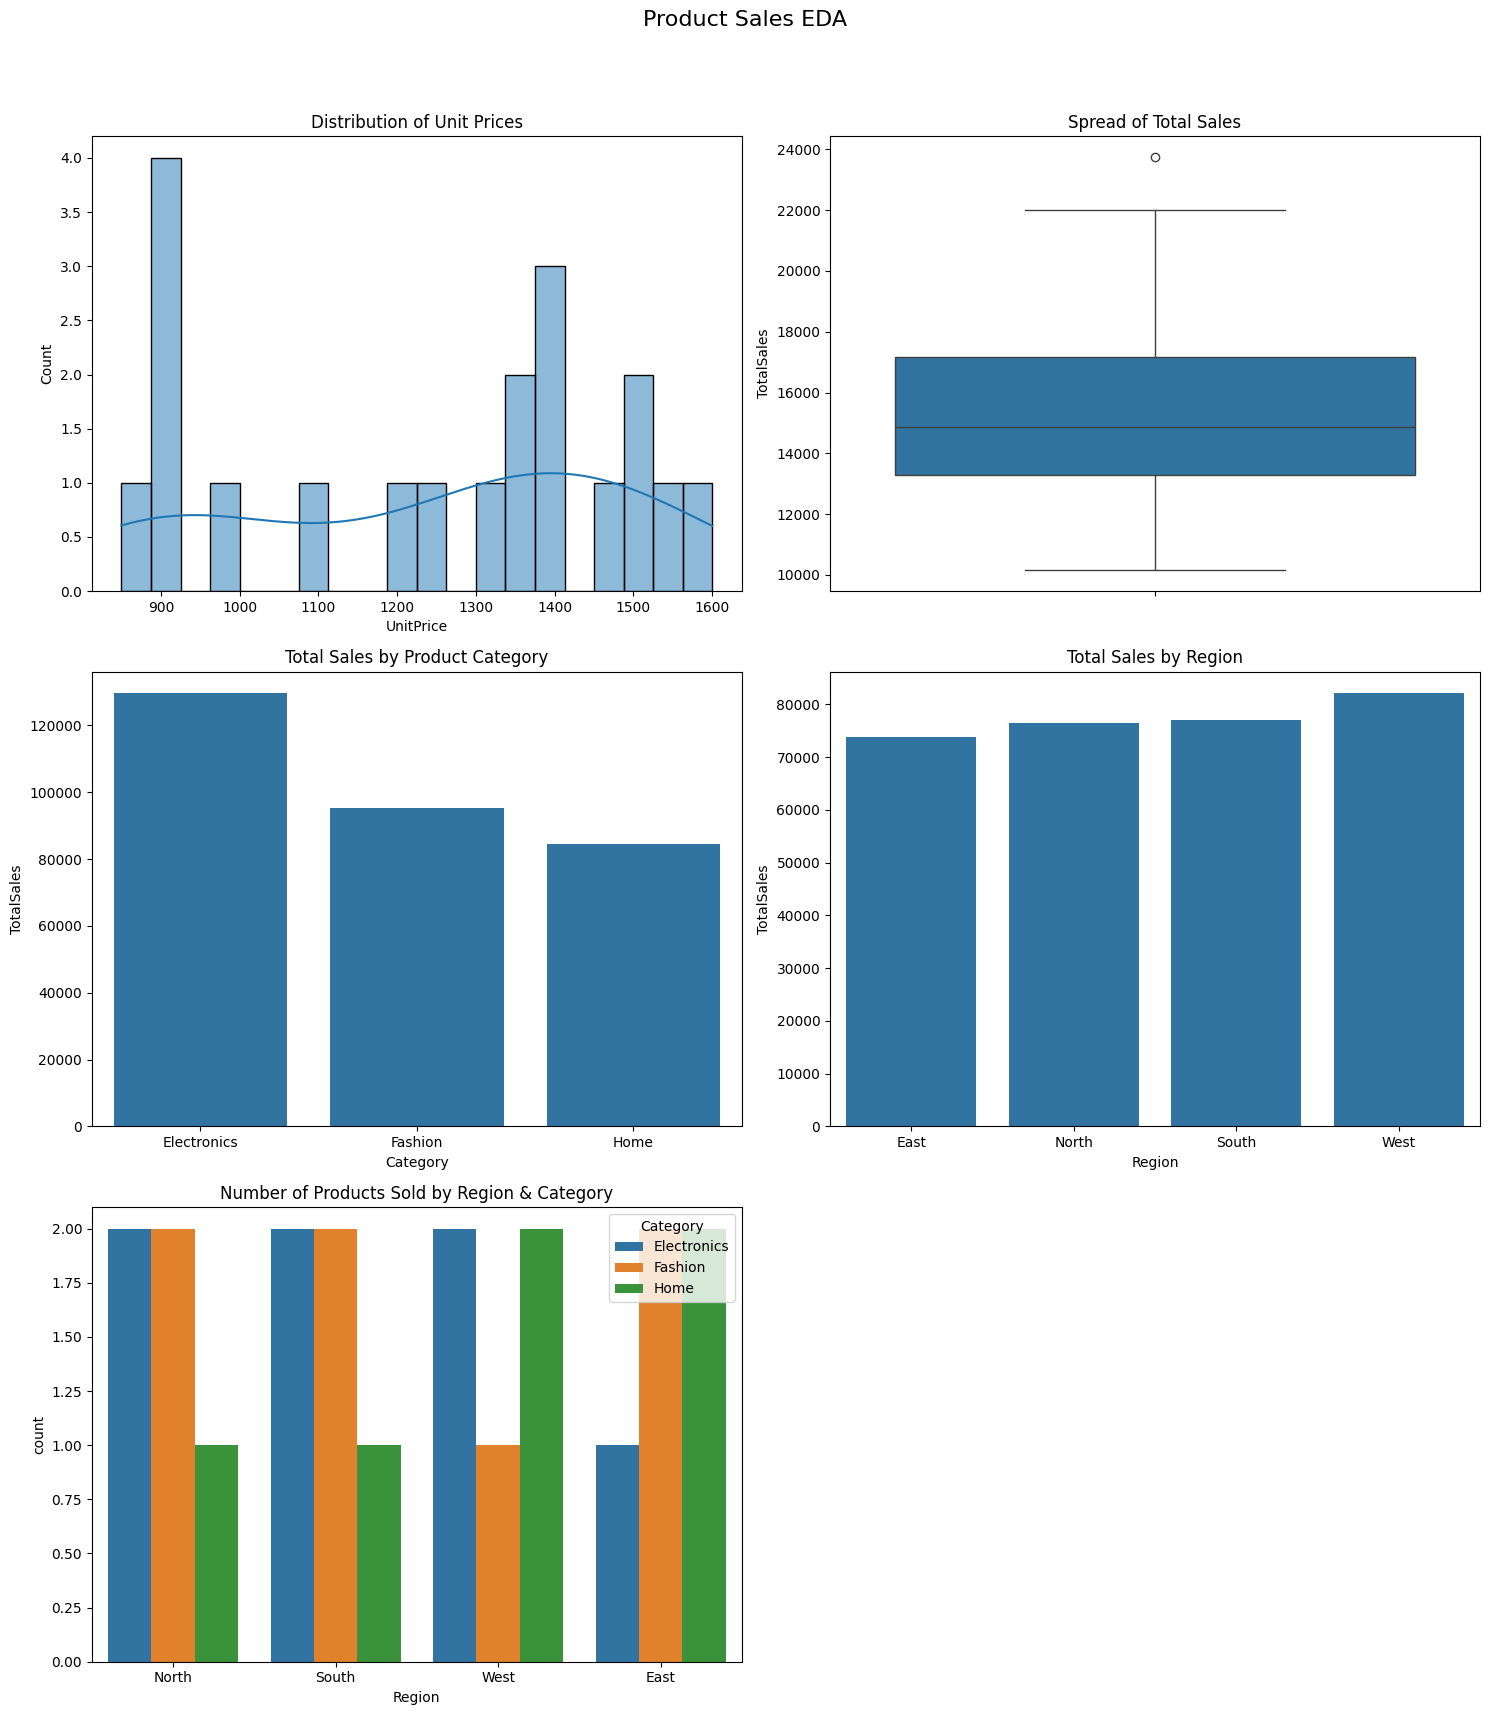

In [9]:
# Question 4(b) — EDA on Product Sales
try:
    df_prod_sales = pd.read_csv('product_sales.csv')
except FileNotFoundError:
    np.random.seed(42)
    df_prod_sales = pd.DataFrame({
        'Category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Beauty'], 200),
        'UnitPrice': np.random.uniform(10, 500, 200),
        'Quantity': np.random.randint(1, 10, 200),
        'Region': np.random.choice(['North', 'South', 'East', 'West'], 200)
    })
    df_prod_sales['TotalSales'] = df_prod_sales['UnitPrice'] * df_prod_sales['Quantity']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Product Sales EDA', fontsize=16)

# Univariate Analysis
# i. Histogram of Unit Prices
sns.histplot(df_prod_sales['UnitPrice'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Unit Prices')

# ii. Box plot of Total Sales
sns.boxplot(data=df_prod_sales, y='TotalSales', ax=axes[0, 1])
axes[0, 1].set_title('Spread of Total Sales')

# Bivariate Analysis
# iii. Top-selling product categories using total sales
sales_by_category = df_prod_sales.groupby('Category')['TotalSales'].sum().reset_index()
sns.barplot(data=sales_by_category, x='Category', y='TotalSales', ax=axes[1, 0])
axes[1, 0].set_title('Total Sales by Product Category')

# iv. Regional sales performance
sales_by_region = df_prod_sales.groupby('Region')['TotalSales'].sum().reset_index()
sns.barplot(data=sales_by_region, x='Region', y='TotalSales', ax=axes[1, 1])
axes[1, 1].set_title('Total Sales by Region')

# v. Count plot of products sold across regions and categories
sns.countplot(data=df_prod_sales, x='Region', hue='Category', ax=axes[2, 0])
axes[2, 0].set_title('Number of Products Sold by Region & Category')

# Hide the empty subplot
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Question 5 - Exploratory Data Analysis (EDA): Multivariate Analysis

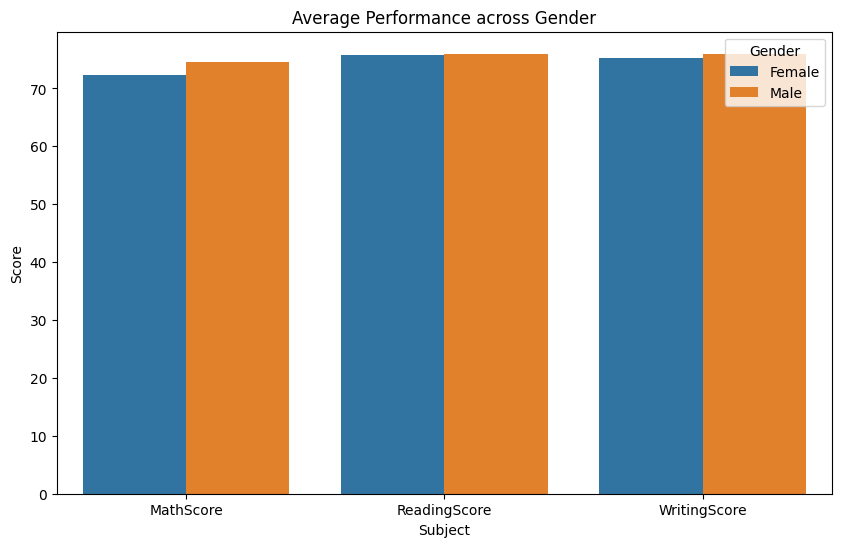

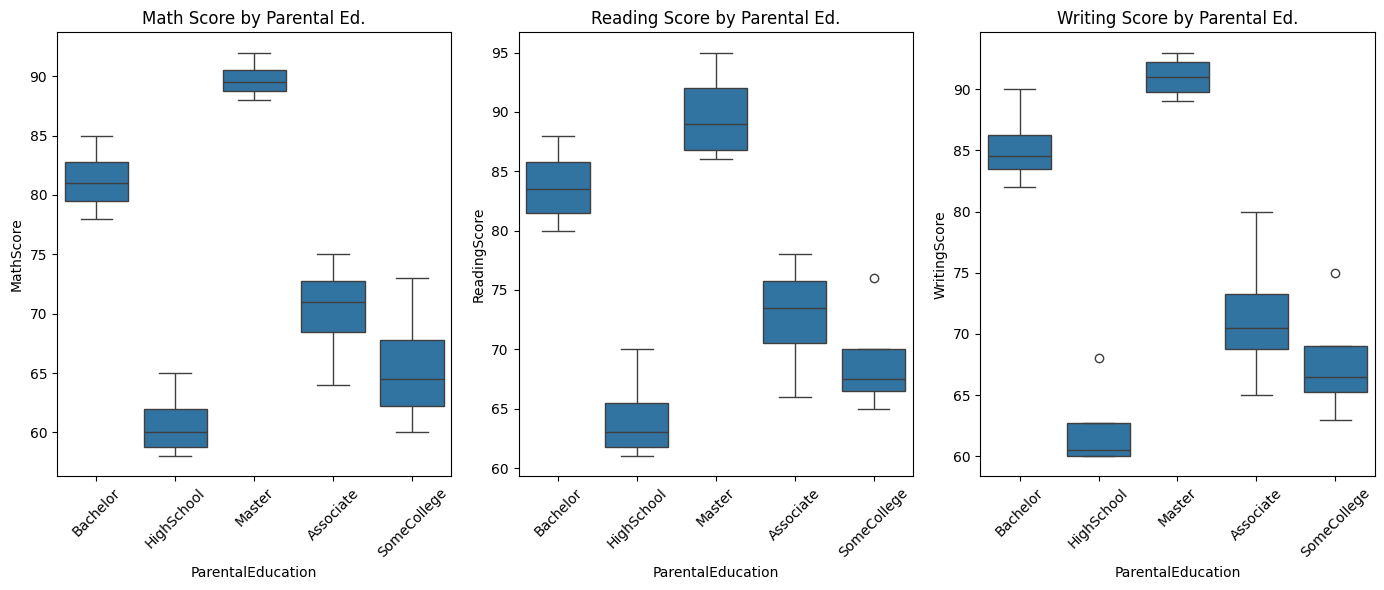

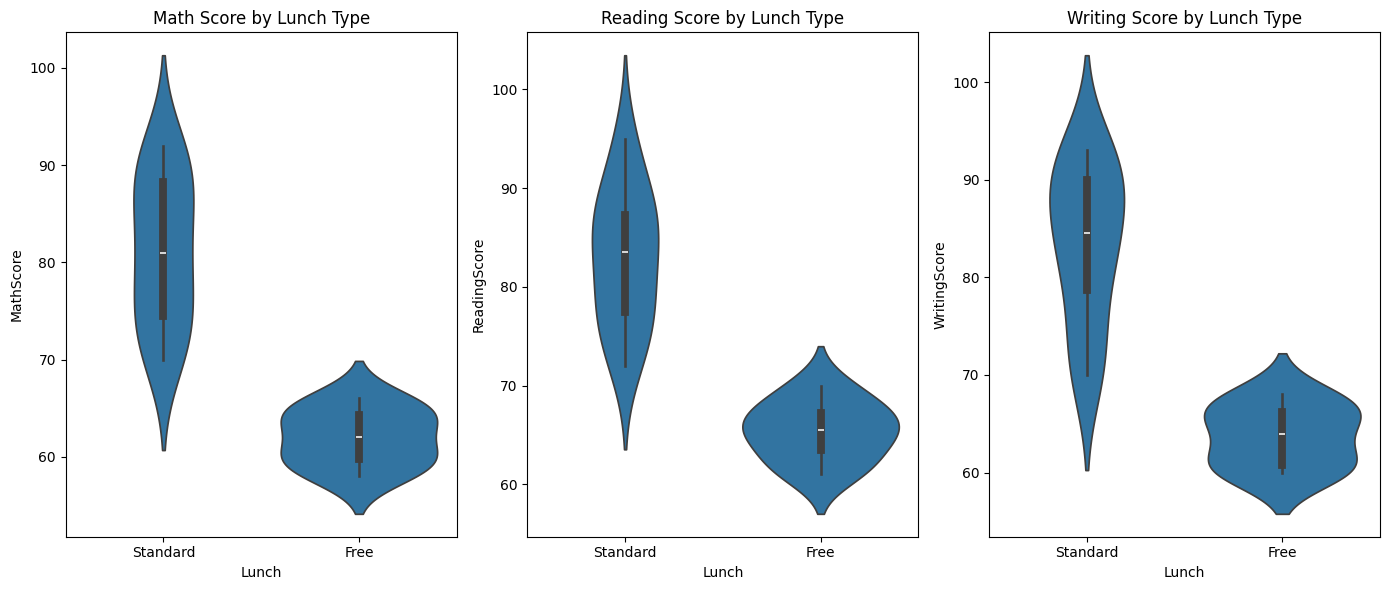

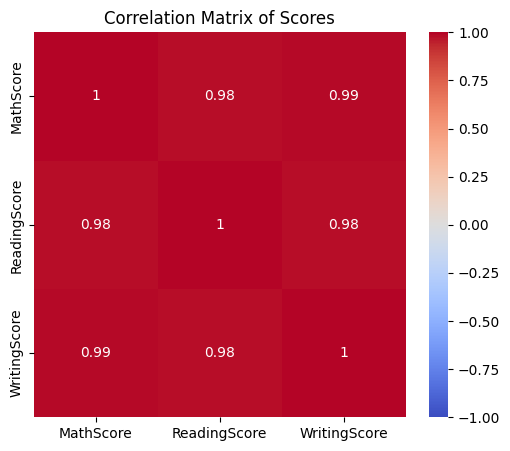

Generating Pairplot...


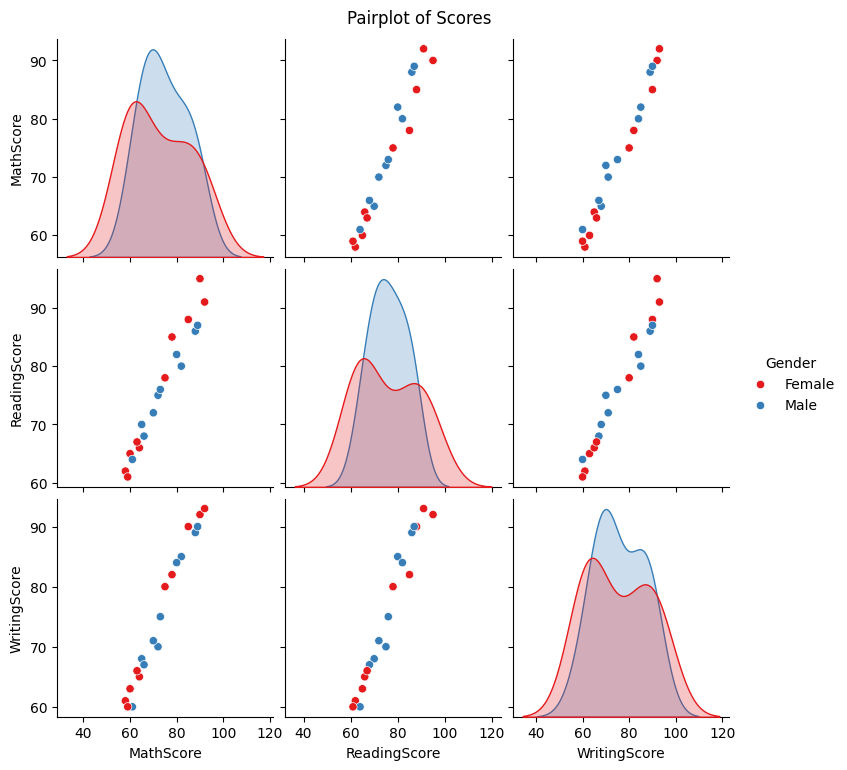

In [10]:
# Question 5(a) — Multivariate Analysis on Student Scores
try:
    df_scores = pd.read_csv('student_scores.csv')
except FileNotFoundError:
    np.random.seed(42)
    df_scores = pd.DataFrame({
        'Gender': np.random.choice(['Male', 'Female'], 150),
        'ParentalEducation': np.random.choice(['High School', 'Bachelor', 'Master', 'Associate'], 150),
        'Lunch': np.random.choice(['Standard', 'Free/Reduced'], 150),
        'MathScore': np.random.randint(40, 100, 150),
        'ReadingScore': np.random.randint(40, 100, 150),
        'WritingScore': np.random.randint(40, 100, 150)
    })

# i. Grouped bar chart for average performance by gender
scores_melted = df_scores.melt(id_vars=['Gender'], value_vars=['MathScore', 'ReadingScore', 'WritingScore'], 
                               var_name='Subject', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=scores_melted, x='Subject', y='Score', hue='Gender', errorbar=None)
plt.title('Average Performance across Gender')
plt.show()

# ii. Box plots for scores grouped by parental education
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_scores, x='ParentalEducation', y='MathScore')
plt.xticks(rotation=45)
plt.title('Math Score by Parental Ed.')

plt.subplot(1, 3, 2)
sns.boxplot(data=df_scores, x='ParentalEducation', y='ReadingScore')
plt.xticks(rotation=45)
plt.title('Reading Score by Parental Ed.')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_scores, x='ParentalEducation', y='WritingScore')
plt.xticks(rotation=45)
plt.title('Writing Score by Parental Ed.')

plt.tight_layout()
plt.show()

# iii. Violin plots for impact of lunch type
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.violinplot(data=df_scores, x='Lunch', y='MathScore')
plt.title('Math Score by Lunch Type')

plt.subplot(1, 3, 2)
sns.violinplot(data=df_scores, x='Lunch', y='ReadingScore')
plt.title('Reading Score by Lunch Type')

plt.subplot(1, 3, 3)
sns.violinplot(data=df_scores, x='Lunch', y='WritingScore')
plt.title('Writing Score by Lunch Type')

plt.tight_layout()
plt.show()

# iv. Correlation Heatmap and Pairplot
scores_only = df_scores[['MathScore', 'ReadingScore', 'WritingScore']]
corr_matrix = scores_only.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Scores')
plt.show()

print("Generating Pairplot...")
sns.pairplot(df_scores, vars=['MathScore', 'ReadingScore', 'WritingScore'], hue='Gender', palette='Set1')
plt.suptitle('Pairplot of Scores', y=1.02)
plt.show()